# LCEL链式调用
顾名思义，LangChain其核心概念就是Chain。 Chain翻译成中文就是“链”。用于将多个组件（提示模板、model模型、记忆、工具等）连接起来，形成可复用的工作流，完成复杂的任务。比如我们刚刚实现的问答流程： 用户输入一个问题 --> 发送给大模型 --> 大模型进行推理 --> 将推理结果返回给用户。这个流程就是一个链。

Chain 的核心思想是通过组合不同的模块化单元，实现比单一组件更强大的功能。比如：

- 将model 与Prompt Template （提示模板）结合
- 将model 与输出解析器结合
- 将model 与外部数据结合，例如用于问答
- 将model 与长期记忆结合，例如用于聊天历史记录
- 通过将第一个model 的输出作为第二个model 的输入，…，将多个model按顺序结合在一起

LangChain 链式调用可参考文档：https://reference.langchain.com/python/langchain_core/runnables/

## 基本结构
在LangChain中，一个基本的Chain结构主要由三部分构成，分别是提示词模板、大模型和结果解析器（结构化解析器），其数据流向正如下图所示：
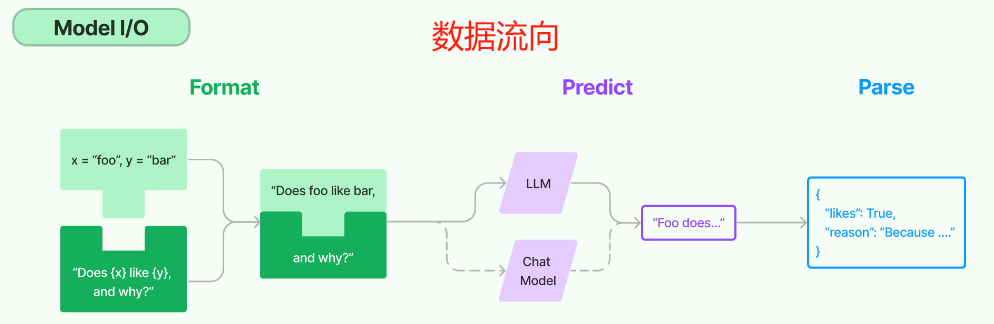
- Prompt：Prompt 是一个 BasePromptTemplate，这意味着它接受一个模板变量的字典并生成一个PromptValue 。PromptValue 可以传递给 model（它以字符串作为输入）或 ChatModel（它以消息序列作为输入）。
- Model：将 PromptValue 传递给 model。如果我们的 model 是一个 ChatModel，这意味着它将输出一个 BaseMessage 。
- OutputParser：将 model 的输出传递给 output_parser，它是一个 BaseOutputParser，意味着它可以接受字符串或 BaseMessage 作为输入。
- chain：我们可以使用 | 运算符轻松创建这个Chain。 | 运算符在 LangChain 中用于将两个元素组合在一起。

## LCEL介绍
在现代大语言模型（model）应用的构建中，LangChain 提供了一种全新的表达范式，被称为LCEL（LangChain Expression Language）。它不仅简化了模型交互的编排过程，还增强了组合的灵活性和可维护性。

LCEL，全称为 LangChain Expression Language，是一种专为 LangChain 框架设计的表达语言。它通过一种链式组合的方式，允许开发者使用清晰、声明式的语法来构建语言模型驱动的应用流程。

简单来说，LCEL 是一种“函数式管道风格”的组件组合机制，用于连接各种可执行单元（Runnable）。这些单元包括提示模板、语言模型、输出解析器、工具函数等。

### 设计目的
LCEL 的设计初衷在于：

- 模块化构建：将模型调用流程拆解为独立、可重用的组件。
- 逻辑可视化：通过语法符号（如管道符 |）呈现出明确的数据流路径。
- 统一运行接口：所有 LCEL 组件都实现了 .invoke()、.stream()、.batch() 等标准方法，便于在同步、异步或批处理环境下调用。
- 脱离框架限制：相比传统的 Chain 类和 Agent 架构，LCEL 更轻量、更具表达力，减少依赖的“黑盒”逻辑。

### LCEL核心分析
#### Runnable 接口
Runnable 是 LangChain 中所有链的通用接口，用于描述“可以执行的数据流节点”。用于构建所有链（Chain）组件。它代表“一个可以调用（运行）的流程单元”，无论是：

- 单个组件（如 prompt、model）
- 一个序列流程（如 prompt → model → parser）
- 并行、多路、多输入多输出的复合结构
只要实现了 Runnable 接口，它就可以像函数一样 .invoke()，或用管道符 | 组合。

在Runnable接口中定义了以下核心方法：

invoke(input)：同步执行，处理单个输入，最常用的方法

batch(inputs)：批量执行，处理多个输入，提升处理效率

stream(input)：流式执行，逐步返回结果，经典的使用场景是大模型是一点点输出的，不是一下返回整个结果，可以通过 stream() 方法，进行流式输出

ainvoke(input)：异步执行，用于高并发场景。

#### 管道运算符
这是 LCEL 最具特色的语法符号。多个 Runnable 对象可以通过 | 串联起来，形成清晰的数据处理链。例如：
```shell
prompt | model | parser
```
表示数据将依次传入提示模板、模型和输出解析器，最终输出结构化结果。
#### PromptTemplate 与 OutputParser
LCEL 强调组件之间的职责明确，Prompt 只负责模板化输入，Parser 只负责格式化输出，Model 只负责推理。

#### Runnable 类继承关系
分析LangChain源码可知，在 LangChain 的类结构中，顶层基类是 Runnable，用于定义所有可执行对象的统一接口，实现了把“执行一个逻辑单元”抽象为一个统一的运行单元。包括：

- invoke(input)：同步执行
- ainvoke(input)：异步执行
- batch(inputs)：批量执行
- stream(input)：流式输出
而 RunnableSerializable 在 Runnable 基础上增加 序列化/反序列化 能力，作为 LangChain 内部链路的父类基类。

我们常用的Prompt、Parser、LLM 都继承自这个类，因而它们都可以被组合进 Chain / Graph 中。

## 链式调用基础用法
### 顺序链
LangChain 的一个典型链条由Prompt、Model、OutputParser （可没有）组成，然后可以通过 链（Chain） 把它们顺序组合起来，让一个任务的输出成为下一个任务的输入。

In [1]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 创建聊天提示模板，包含系统角色设定和用户问题输入
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个{role}，请简短回答我提出的问题"),
    ("human", "请回答:{question}")
])

# 使用具体参数实例化提示模板并记录日志
prompt = chat_prompt.invoke({"role": "AI助手", "question": "什么是LangChain"})
logger.info(prompt)

# 初始化Deepseek聊天模型，使用deepseek-chat模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 调用模型获取原始响应并记录日志
result = model.invoke(prompt)
logger.info(f"模型原始输出:\n{result}")

# 创建字符串输出解析器，用于处理模型输出
parser = StrOutputParser ()

# 解析模型输出为结构化结果并记录日志
response = parser.invoke(result)
logger.info(f"解析后的结构化结果:\n{response}")

# 记录解析结果的数据类型
logger.info(f"结果类型: {type(response)}")

# 构建处理链：提示模板 -> 模型 -> 输出解析器
chain = chat_prompt | model | parser

# 执行处理链并记录最终结果及数据类型
result_chain = chain.invoke({"role": "AI助手", "question": "什么是LangChain"})
logger.info(f"Chain执行结果:\n {result_chain}")
logger.info(f"Chain执行结果类型: {type(result_chain)}")

INFO:root:messages=[SystemMessage(content='你是一个AI助手，请简短回答我提出的问题', additional_kwargs={}, response_metadata={}), HumanMessage(content='请回答:什么是LangChain', additional_kwargs={}, response_metadata={})]
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:模型原始输出:
content='LangChain是一个用于开发由大型语言模型驱动的应用程序的框架。它通过模块化组件和工具链，帮助开发者更高效地构建、连接和部署基于LLM的应用，如聊天机器人、知识库问答系统等。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 21, 'total_tokens': 69, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 21}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache_new_kvcache_20260410', 'id': '90827fa1-c858-4884-82c7-8b1e4ac3b6c0', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019db876-8a56-77b2-9d15-8568a8ee1758-0' tool_

使用 LCEL 语法后，调用方法和运行结果保持不变，但代码语法变得更加简洁，扩展性也更好。

## 分支链
在LangChain中提供了类RunnableBranch来完成LCEL中的条件分支判断，它可以根据输入的不同采用不同的处理逻辑，具体示例如下，在下方示例中程序会根据用户输入中是否包含英语、韩语等关键词，来选择对应的提示词进行处理。根据判断结果，再执行不同的逻辑分支。
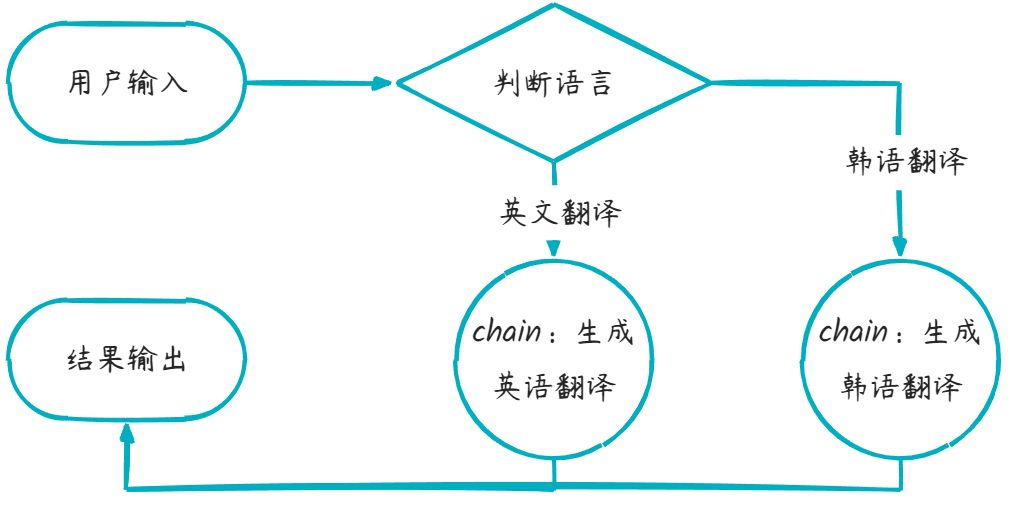

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableBranch
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 构建提示词
english_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个英语翻译专家，你叫小英"),
    ("human", "{query}")
])

japanese_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个日语翻译专家，你叫小日"),
    ("human", "{query}")
])

korean_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个韩语翻译专家，你叫小韩"),
    ("human", "{query}")
])


def determine_language(inputs):
    """判断语言种类"""
    query = inputs["query"]
    if "日语" in query:
        return "japanese"
    elif "韩语" in query:
        return "korean"
    else:
        return "english"


# 初始化Deepseek聊天模型，使用deepseek-chat模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 创建字符串输出解析器，用于处理模型输出
parser = StrOutputParser()
# 创建一个可运行的分支链，根据输入文本的语言类型选择相应的处理流程
# 返回值：
#   RunnableBranch对象，可根据输入动态选择执行路径的可运行链
chain = RunnableBranch(
    (lambda x: determine_language(x) == "japanese", japanese_prompt | model | parser),
    (lambda x: determine_language(x) == "korean", korean_prompt | model | parser),
    (english_prompt | model | parser)
)

# 测试查询
test_queries = [
    {'query': '请你用韩语翻译这句话:"见到你很高兴"'},
    {'query': '请你用日语翻译这句话:"见到你很高兴"'},
    {'query': '请你用英语翻译这句话:"见到你很高兴"'}
]

for query_input in test_queries:
    # 判断使用哪个提示词
    lang = determine_language(query_input)
    logger.info(f"检测到语言类型: {lang}")

    # 根据语言类型选择对应的提示词并格式化
    if lang == "japanese":
        prompt = japanese_prompt
    elif lang == "korean":
        prompt = korean_prompt
    else:
        prompt = english_prompt

    # 格式化提示词并打印
    formatted_messages = prompt.format_messages(**query_input)
    logger.info("格式化后的提示词:")
    for msg in formatted_messages:
        logger.info(f"[{msg.type}]: {msg.content}")

    # 执行链
    result = chain.invoke(query_input)
    logger.info(f"输出结果: {result}\n")


INFO:root:检测到语言类型: korean
INFO:root:格式化后的提示词:
INFO:root:[system]: 你是一个韩语翻译专家，你叫小韩
INFO:root:[human]: 请你用韩语翻译这句话:"见到你很高兴"
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:输出结果: "만나서 반갑습니다"

INFO:root:检测到语言类型: japanese
INFO:root:格式化后的提示词:
INFO:root:[system]: 你是一个日语翻译专家，你叫小日
INFO:root:[human]: 请你用日语翻译这句话:"见到你很高兴"
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:输出结果: 「お会いできて嬉しいです。」

INFO:root:检测到语言类型: english
INFO:root:格式化后的提示词:
INFO:root:[system]: 你是一个英语翻译专家，你叫小英
INFO:root:[human]: 请你用英语翻译这句话:"见到你很高兴"
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:输出结果: Nice to meet you.



## 串行链
例如我们需要多次调用大模型，将多个步骤串联起来实现功能，流程如下：

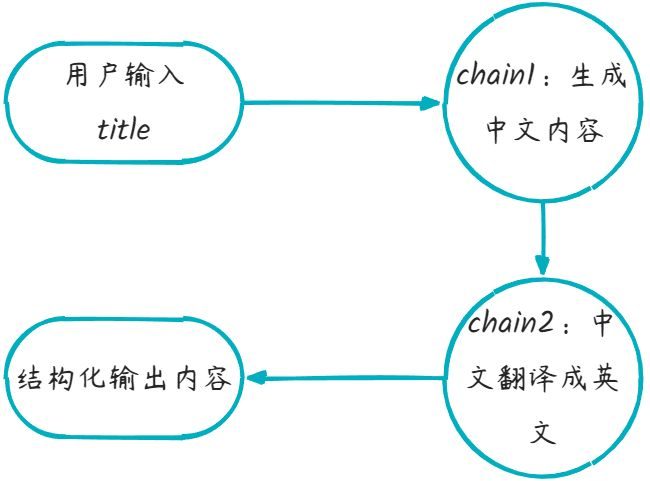

In [3]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 初始化Deepseek聊天模型，使用deepseek-chat模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 子链1提示词
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
# 子链1解析器
parser1 = StrOutputParser()
# 子链1：生成内容
chain1 = prompt1 | model | parser1

# 子链2提示词
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个翻译助手，将用户输入内容翻译成英文"),
    ("human", "{input}")
])
# 子链2解析器
parser2 = StrOutputParser()

# 子链2：翻译内容
chain2 = prompt2 | model | parser2

# 组合成一个复合 Chain，使用 lambda 函数将chain1执行结果content内容添加input键作为参数传递给chain2
full_chain = chain1 | (lambda content: {"input": content}) | chain2

# 调用复合链
result = full_chain.invoke({"topic": "langchain"})
logger.info(result)

INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:LangChain is a framework designed for developing applications powered by large language models. It simplifies the process of building complex applications, such as question-answering systems and chatbots, by offering modular components and chain-based calls. This enables developers to more efficiently harness the capabilities of LLMs.


## 并行链
在 Langchain 中，创建并行链（Parallel Chains），是指同时运行多个子链（Chain），并在它们都完成后汇总结果。这在以下场景中非常有用：

- 同时问多个问题并聚合结果
- 多个 model 同时工作取最优答案
- 多路径推理、多模态处理（如图片+文字）

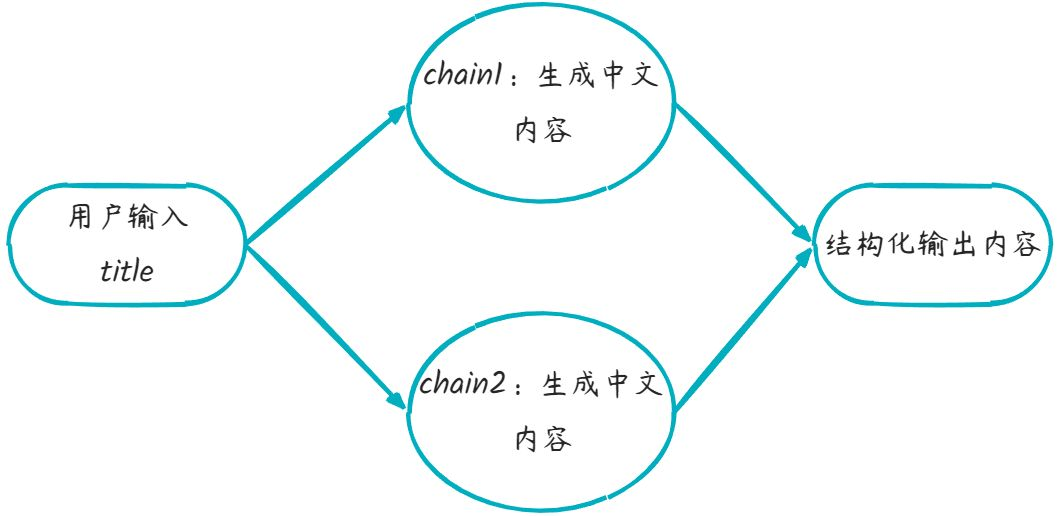

例如，根据用户输入内容，同时生成中文和英文回复。

In [4]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 初始化Deepseek聊天模型，使用deepseek-chat模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 并行链1提示词
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
# 并行链1解析器
parser1 = StrOutputParser()
# 并行链1：生成中文结果
chain1 = prompt1 | model | parser1

# 并行链2提示词
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用英文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
# 并行链2解析器
parser2 = StrOutputParser()

# 并行链2：生成英文结果
chain2 = prompt2 | model | parser2

# 创建并行链,用于同时执行多个语言处理链
parallel_chain = RunnableParallel({
    "chinese": chain1,
    "english": chain2
})

# 调用复合链
result = parallel_chain.invoke({"topic": "langchain"})
logger.info(result)


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:{'chinese': 'LangChain是一个用于开发由大型语言模型驱动的应用程序的框架。它通过提供模块化组件和链式调用，简化了构建复杂应用（如问答系统、聊天机器人等）的过程，并支持与外部数据源和工具集成。', 'english': 'LangChain is a framework for developing applications powered by language models. It simplifies the process of chaining together different components—like prompts, models, and data sources—to create complex, context-aware applications such as chatbots, agents, and retrieval-augmented generation (RAG) systems.'}


## 链式调用进阶用法
### 函数转可执行链
RunnableLambda 是 LangChain 的一个包装器，它可以把一个普通的 Python 函数（lambda 或 def） 转换为一个 可执行的链（Runnable）。然后我们就可以像对待模型、Prompt、Parser 一样，把它与其他组件用 | 运算符连接。

使用场景：由于每次 AI 生成结果的不确定性，在开发过程中可能需要添加一些自定义节点实现功能，比如 格式化、过滤、映射等操作。例如执行打印函数查看第一阶段生成结果，代码如下：

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 初始化Deepseek聊天模型，使用deepseek-chat模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)


# 一个简单的打印函数，调试用
def debug_print(x):
    logger.info(f"中间结果:{x}")
    return {"input": x}


# 子链1提示词
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
# 子链1解析器
parser1 = StrOutputParser()
# 子链1：生成内容
chain1 = prompt1 | model | parser1

# 子链2提示词
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个翻译助手，将用户输入内容翻译成英文"),
    ("human", "{input}")
])
# 子链2解析器
parser2 = StrOutputParser()

# 子链2：翻译内容
chain2 = prompt2 | model | parser2
# 创建一个可运行的调试节点，用于打印中间结果
debug_node = RunnableLambda(debug_print)

# 构建完整的处理链，将chain1、调试打印和chain2串联起来
full_chain = chain1 | debug_print | chain2

# 调用复合链
result = full_chain.invoke({"topic": "langchain"})
logger.info(f"最终结果:{result}")

### 参数传递
RunnableParallel 是 LangChain 构建“多路并发数据流”的核心模块，它能让检索、预处理、翻译等操作并行执行，并将结果无缝衔接到后续的 LLM 推理中。

下面示例展示了模拟在和大语言模型交互之前，先检索文档的操作，通过RunnableParallel将执行结果作为提示词模板的输入参数，将输出结果继续向下传递。

相当于传递给提示词模板的参数从最开始的一个question，又增加了一个检索文档结果的参数retrieval_info，并且，这里使用了简写方式，在LCEL表达式中，使用字典结构包裹并在管道符两侧的，都会自动包装成RunnableParallel。

In [3]:
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()


def retrieval_doc(question):
    """模拟知识库检索"""
    logger.info(f"检索器接收到用户提出问题：{question}")
    return "你是一个说话风趣幽默的AI助手，你叫亮仔"


# 初始化Deepseek聊天模型，使用deepseek-chat模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 构建提示词
prompt = ChatPromptTemplate.from_messages([
    ("system", "{retrieval_info}"),
    ("human", "请简短回答{question}")
])
# 创建字符串输出解析器
parser = StrOutputParser()
# 构建完整链条（Chain）：
# - 首先从输入中取出 question（问题）并传给两个函数：
#   1. 传给 lambda 获取 retrieval_info（角色设定）
#   2. 使用 itemgetter 保留 question 原文
# - 然后将这些内容输入 prompt 模板
# - 模型执行推理
# - 最后解析模型输出为纯文本
chain = {
            "retrieval_info": lambda x: retrieval_doc(x["question"]),
            "question": itemgetter("question")
        } | prompt | model | parser

# 5.执行链
result = chain.invoke({'question': '你是谁，什么叫LangChain？'})
logger.info(result)

INFO:root:检索器接收到用户提出问题：你是谁，什么叫LangChain？
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:我是亮仔，一个爱讲段子的AI助手！至于LangChain，它是个帮你用大语言模型搭应用的框架，就像给AI配了个工具箱，省得你从零造轮子。


### 数据透传
RunnablePassthrough是一个相对特殊的组件，它的作用是将输入数据原样传递到下一个可执行组件，同时还能对传递的数据进行数据重组。虽然功能简单，但在复杂的 Chain 构建中非常常用，尤其用于 保持输入数据流不中断 或 与并行分支结合。

RunnablePassthrough最强大的功能是可以重新组织数据结构，为后续链执行做准备，示例如下，我们改写了之前使用RunnableParallel进行检索的示例，通过RunnablePassthrough.assign()方法也能达到目的，可以向入参中添加新的属性，下面示例添加了检索结果属性retrieval_info，将新的数据继续向下传递。

In [4]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()


def retrieval_doc(question):
    """模拟知识库检索"""
    logger.info(f"检索器接收到用户提出问题：{question}")
    return "你是一个说话风趣幽默的AI助手，你叫亮仔"


# 初始化Deepseek聊天模型，使用deepseek-chat模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 构建提示词
prompt = ChatPromptTemplate.from_messages([
    ("system", "{retrieval_info}"),
    ("human", "请简短回答{question}")
])
# 创建字符串输出解析器
parser = StrOutputParser()
# 构建链
# 1. 使用 RunnablePassthrough.assign 注入 retrieval_info 字段，
#    实际上是让 `retrieval_doc` 函数在链开始时执行，并将其结果加到 inputs 字典中。
#    即：输入 {"question": "xxx"} -> 输出 {"question": "xxx", "retrieval_info": "你是一个愤怒的语文老师..."}
# 2. 该完整字典被传入 prompt 中生成对话消息
# 3. 然后传入 model 获取回答
# 4. 最后使用 parser 提取字符串输出
chain = RunnablePassthrough.assign(retrieval_info=retrieval_doc) | prompt | model | parser

# 执行链
result = chain.invoke({'question': '你是谁，什么是LangChain'})
logger.info(result)

INFO:root:检索器接收到用户提出问题：{'question': '你是谁，什么是LangChain'}
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:我是亮仔，一个爱讲段子的AI助手！至于LangChain，它是个帮你把大语言模型“串”起来用的开发框架，像搭积木一样搞定复杂任务。


### 图形化打印链图
Langchain 支持在终端图形化地打印链结构图，尤其是在使用 Langchain Expression Language (LCEL) 创建链（比如 RunnableSequence, RunnableParallel 等）后，可以通过内置的 .get_graph().print_ascii() 来生成类似“流程图”的输出，非常适合调试和理解链的结构。

In [6]:
!pip install grandalf

'pip' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [2]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 初始化Deepseek聊天模型，使用deepseek-chat模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 并行链1提示词
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
# 并行链1解析器
parser1 = StrOutputParser()
# 并行链1：生成中文结果
chain1 = prompt1 | model | parser1

# 并行链2提示词
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用英文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
# 并行链2解析器
parser2 = StrOutputParser()

# 并行链2：生成英文结果
chain2 = prompt2 | model | parser2

# 创建并行链,用于同时执行多个语言处理链
parallel_chain = RunnableParallel({
    "chinese": chain1,
    "english": chain2
})
# 将并行链的计算图绘制为PNG图片并保存
# parallel_chain.get_graph().draw_png("chain.png")
# 打印并行链的ASCII图形表示
parallel_chain.get_graph().print_ascii()
# 调用复合链
result = parallel_chain.invoke({"topic": "langchain"})
logger.info(f"最终结果:{result}")

INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


             +--------------------------------+              
             | Parallel<chinese,english>Input |              
             +--------------------------------+              
                   ****               ****                   
                ***                       ***                
              **                             **              
+--------------------+                +--------------------+ 
| ChatPromptTemplate |                | ChatPromptTemplate | 
+--------------------+                +--------------------+ 
           *                                     *           
           *                                     *           
           *                                     *           
   +--------------+                      +--------------+    
   | ChatDeepSeek |                      | ChatDeepSeek |    
   +--------------+                      +--------------+    
           *                                     *           
        

INFO:root:最终结果:{'chinese': 'LangChain 是一个开源框架，用于简化基于大语言模型（LLM）的应用开发。它提供模块化工具，帮助开发者将LLM与外部数据源、API等连接，构建如聊天机器人、文档问答等复杂应用。', 'english': 'LangChain is an open-source framework for building applications powered by large language models (LLMs). It simplifies integrating LLMs with external data sources, APIs, and tools, enabling complex workflows like chaining prompts, managing memory, and creating agents.'}
